In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/heeraldedhia/groceries-dataset/Groceries_dataset.csv


In [3]:
import pandas as pd

df = pd.read_csv(
    "/kaggle/input/datasets/heeraldedhia/groceries-dataset/Groceries_dataset.csv"
)

print(df.head())

   Member_number        Date   itemDescription
0           1808  21-07-2015    tropical fruit
1           2552  05-01-2015        whole milk
2           2300  19-09-2015         pip fruit
3           1187  12-12-2015  other vegetables
4           3037  01-02-2015        whole milk


In [4]:
"""
Some important terms:

    Support: This says how popular an itemset is, as measured by the proportion of transactions 
                in which an itemset appears.

    Confidence: This says how likely item Y is purchased when item X is purchased, expressed as {X -> Y}. 
                This is measured by the proportion of transactions with item X, in which item Y also appears.

    Lift: This says how likely item Y is purchased when item X is purchased while controlling 
            for how popular item Y is.

"""

'\nSome important terms:\n\n    Support: This says how popular an itemset is, as measured by the proportion of transactions \n                in which an itemset appears.\n\n    Confidence: This says how likely item Y is purchased when item X is purchased, expressed as {X -> Y}. \n                This is measured by the proportion of transactions with item X, in which item Y also appears.\n\n    Lift: This says how likely item Y is purchased when item X is purchased while controlling \n            for how popular item Y is.\n\n'

In [5]:
df

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk
...,...,...,...
38760,4471,08-10-2014,sliced cheese
38761,2022,23-02-2014,candy
38762,1097,16-04-2014,cake bar
38763,1510,03-12-2014,fruit/vegetable juice


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38765 entries, 0 to 38764
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Member_number    38765 non-null  int64 
 1   Date             38765 non-null  object
 2   itemDescription  38765 non-null  object
dtypes: int64(1), object(2)
memory usage: 908.7+ KB


In [7]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

/tmp/ipykernel_58/2263964175.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce')


In [8]:
df['itemDescription'].value_counts()

itemDescription
whole milk               2502
other vegetables         1898
rolls/buns               1716
soda                     1514
yogurt                   1334
                         ... 
rubbing alcohol             5
bags                        4
baby cosmetics              3
kitchen utensil             1
preservation products       1
Name: count, Length: 167, dtype: int64

In [9]:
df['Member_number'].value_counts()

Member_number
3180    36
3737    33
3050    33
2051    33
3915    31
        ..
4590     2
4703     2
3607     2
4587     2
2417     2
Name: count, Length: 3898, dtype: int64

In [10]:
df['itemDescription'].value_counts()

itemDescription
whole milk               2502
other vegetables         1898
rolls/buns               1716
soda                     1514
yogurt                   1334
                         ... 
rubbing alcohol             5
bags                        4
baby cosmetics              3
kitchen utensil             1
preservation products       1
Name: count, Length: 167, dtype: int64

In [11]:
df['itemDescription'].groupby(df['Member_number']).value_counts()

Member_number  itemDescription    
1000           sausage                2
               whole milk             2
               canned beer            1
               hygiene articles       1
               misc. beverages        1
                                     ..
5000           onions                 1
               other vegetables       1
               root vegetables        1
               semi-finished bread    1
               soda                   1
Name: count, Length: 34766, dtype: int64

In [12]:
df['Member_number'].groupby(df['itemDescription']).value_counts()

itemDescription        Member_number
Instant food products  1038             1
                       1045             1
                       1061             1
                       1092             1
                       1298             1
                                       ..
zwieback               4765             1
                       4809             1
                       4828             1
                       4836             1
                       4879             1
Name: count, Length: 34766, dtype: int64

In [13]:
df.head()

,Member_number,Date,itemDescription
0,1808,2015-07-21,tropical fruit
1,2552,2015-01-05,whole milk
2,2300,2015-09-19,pip fruit
3,1187,2015-12-12,other vegetables
4,3037,2015-02-01,whole milk


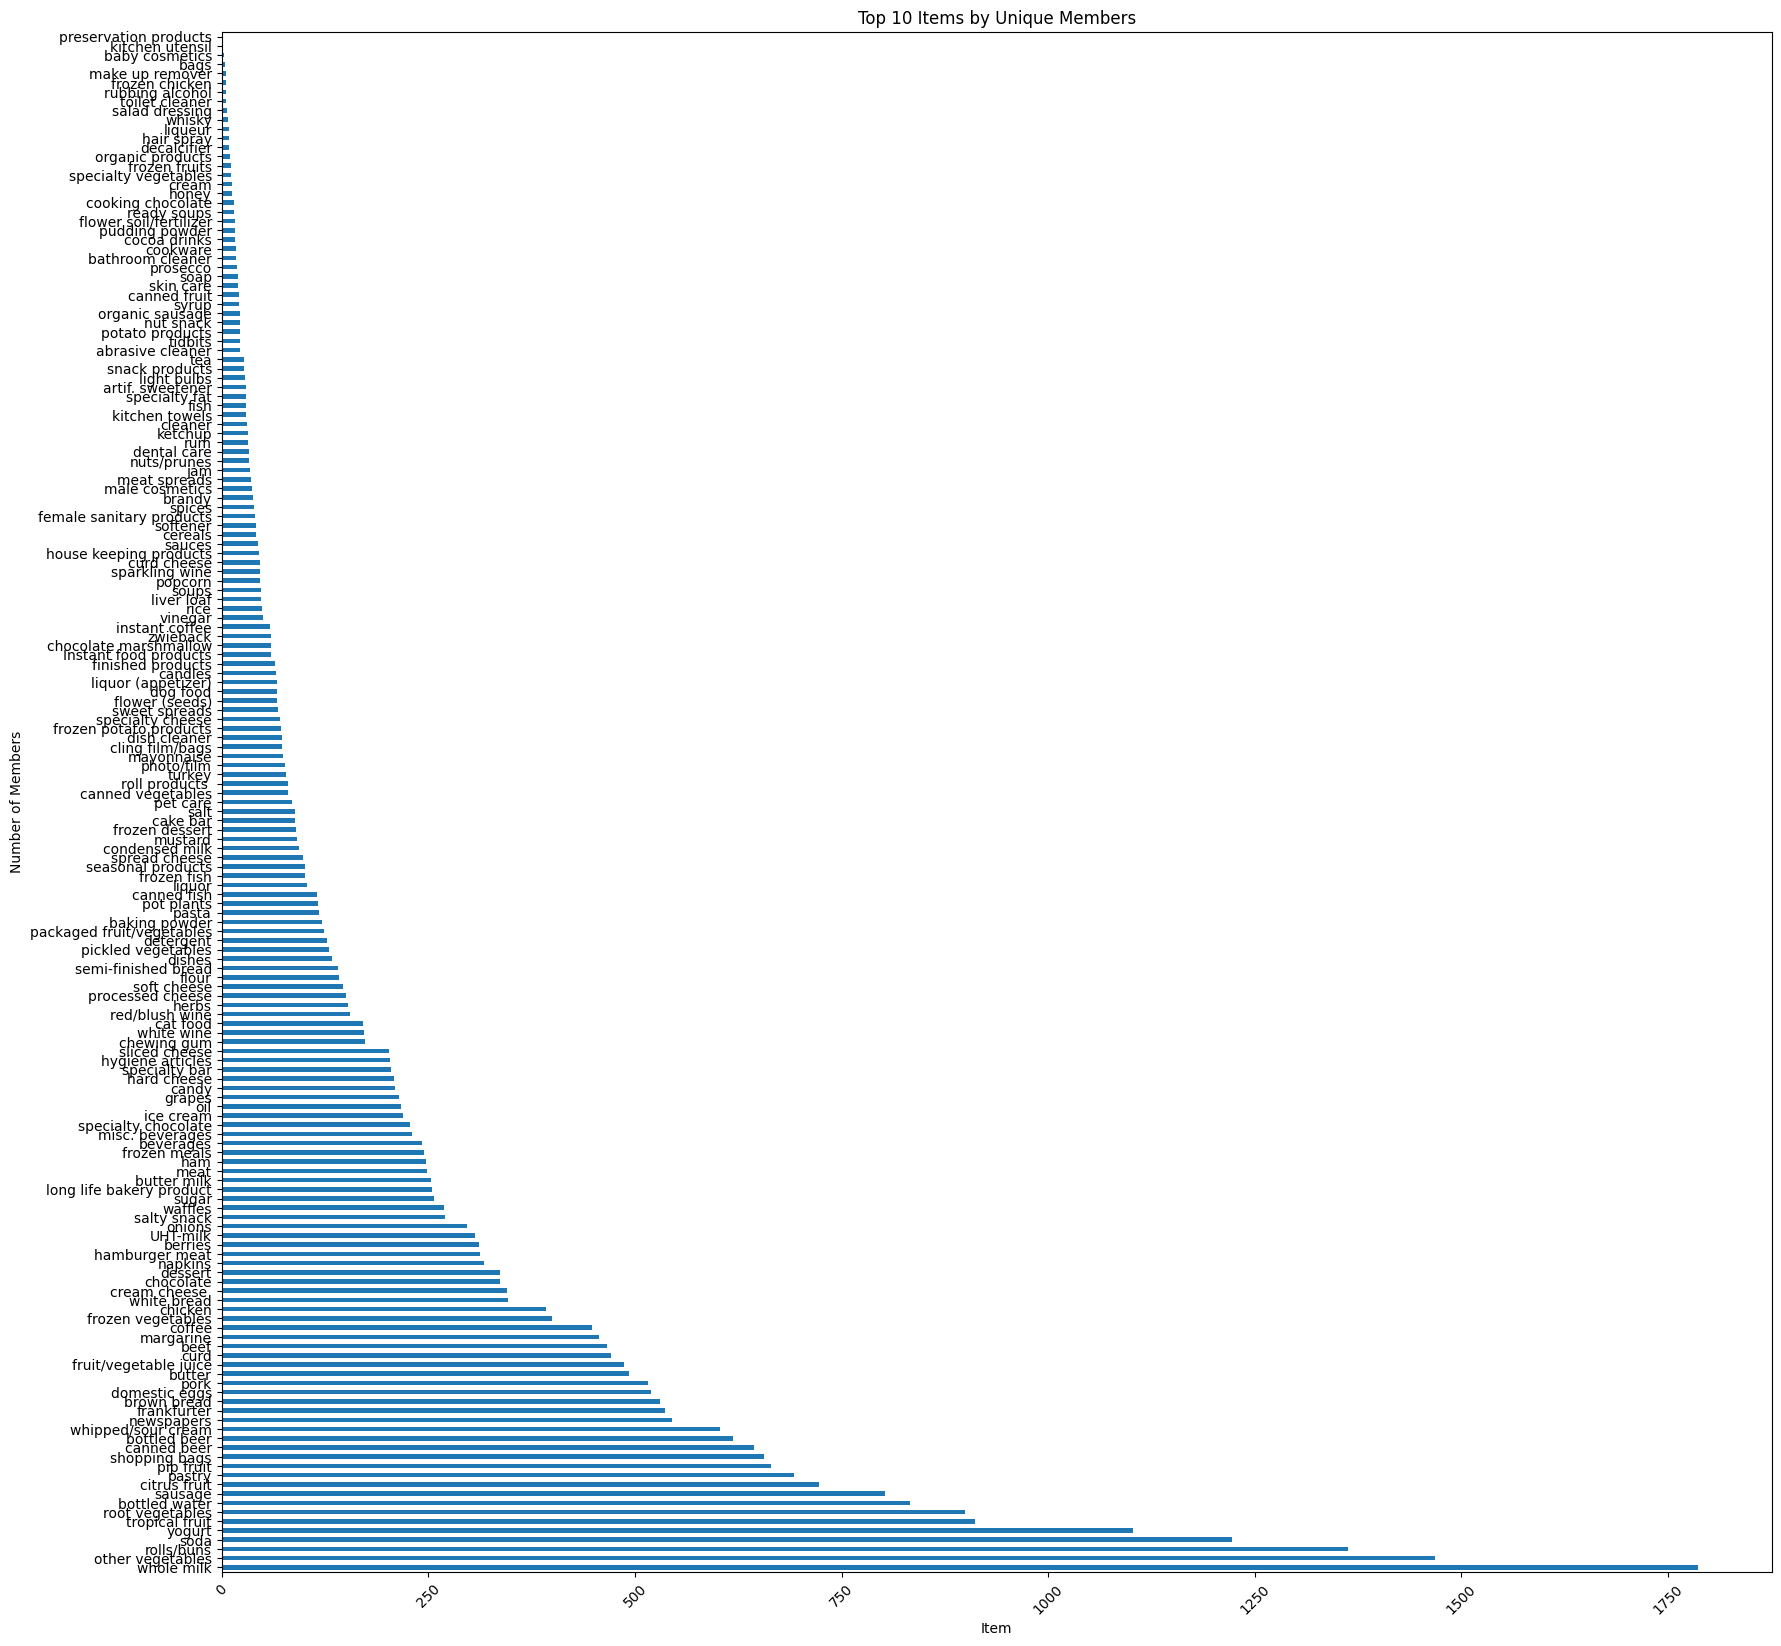

In [14]:
item_counts = df.groupby('itemDescription')['Member_number'].nunique()
#item_counts = item_counts.sort_values(ascending=False).head(10)
item_counts = item_counts.sort_values(ascending=False)

import matplotlib.pyplot as plt

plt.figure(figsize=(20,20))
item_counts.plot(kind='barh')
plt.title('Top 10 Items by Unique Members')
plt.ylabel('Number of Members')
plt.xlabel('Item')
plt.xticks(rotation=45)
plt.show()

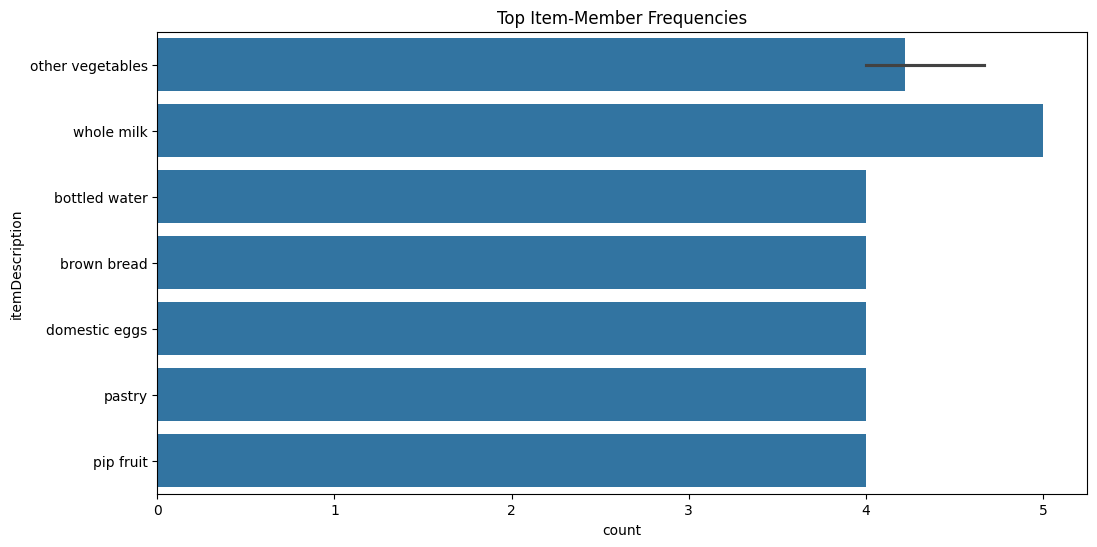

In [15]:
counts = (
    df.groupby('itemDescription')['Member_number']
      .value_counts()
      .reset_index(name='count')
)

top_counts = counts.nlargest(20, 'count')

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.barplot(data=top_counts,
            x='count',
            y='itemDescription')

plt.title('Top Item-Member Frequencies')
plt.show()

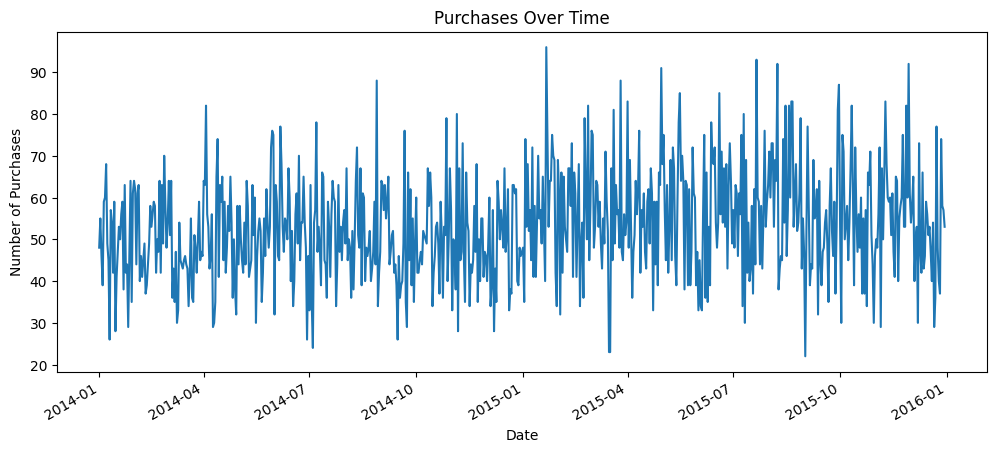

In [16]:
import matplotlib.pyplot as plt

df['Date'] = pd.to_datetime(df['Date'])

daily_sales = (
    df.groupby('Date')['Member_number']
      .count()
)

daily_sales.plot(figsize=(12,5))
plt.title('Purchases Over Time')
plt.ylabel('Number of Purchases')
plt.show()

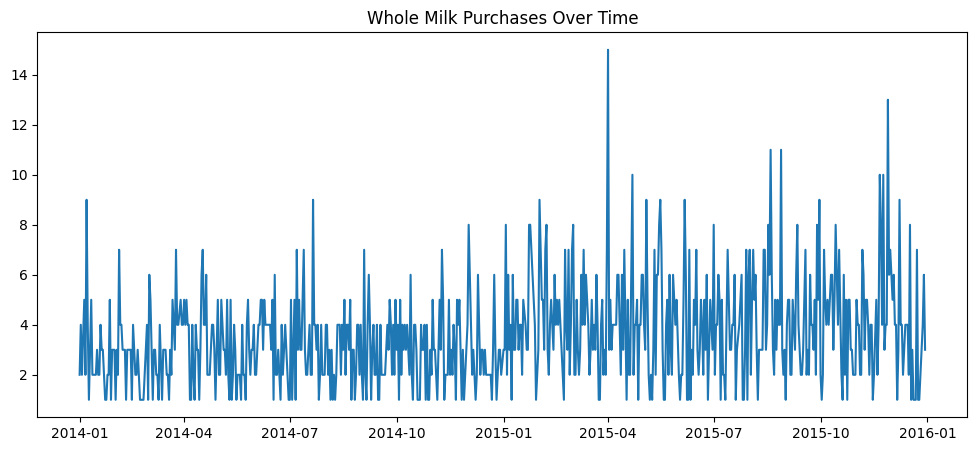

In [17]:
item_date = (
    df.groupby(['Date', 'itemDescription'])
      .size()
      .reset_index(name='count')
)

milk_sales = item_date[item_date['itemDescription'] == 'whole milk']

plt.figure(figsize=(12,5))
plt.plot(milk_sales['Date'], milk_sales['count'])
plt.title('Whole Milk Purchases Over Time')
plt.show()

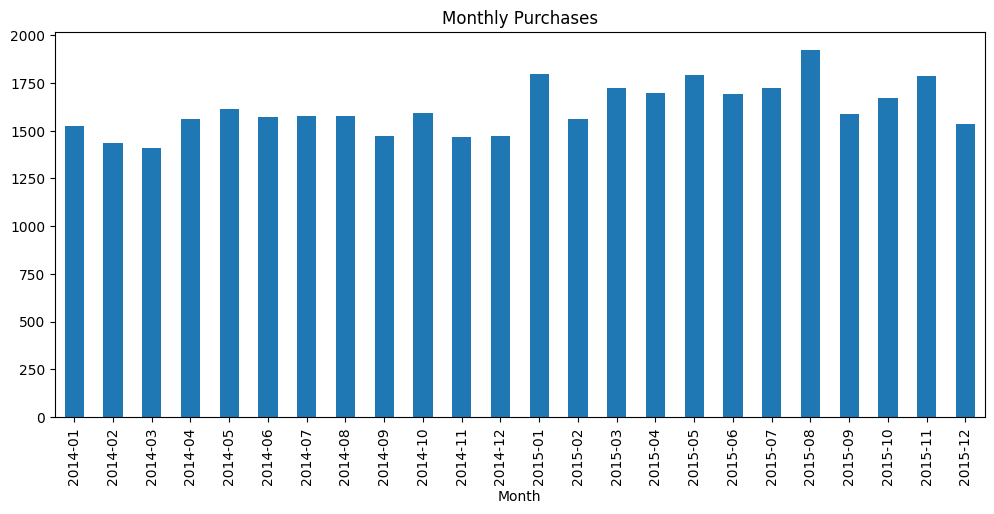

In [18]:
df['Month'] = pd.to_datetime(df['Date']).dt.to_period('M')

monthly_sales = (
    df.groupby('Month')
      .size()
)

monthly_sales.plot(kind='bar', figsize=(12,5))
plt.title('Monthly Purchases')
plt.show()

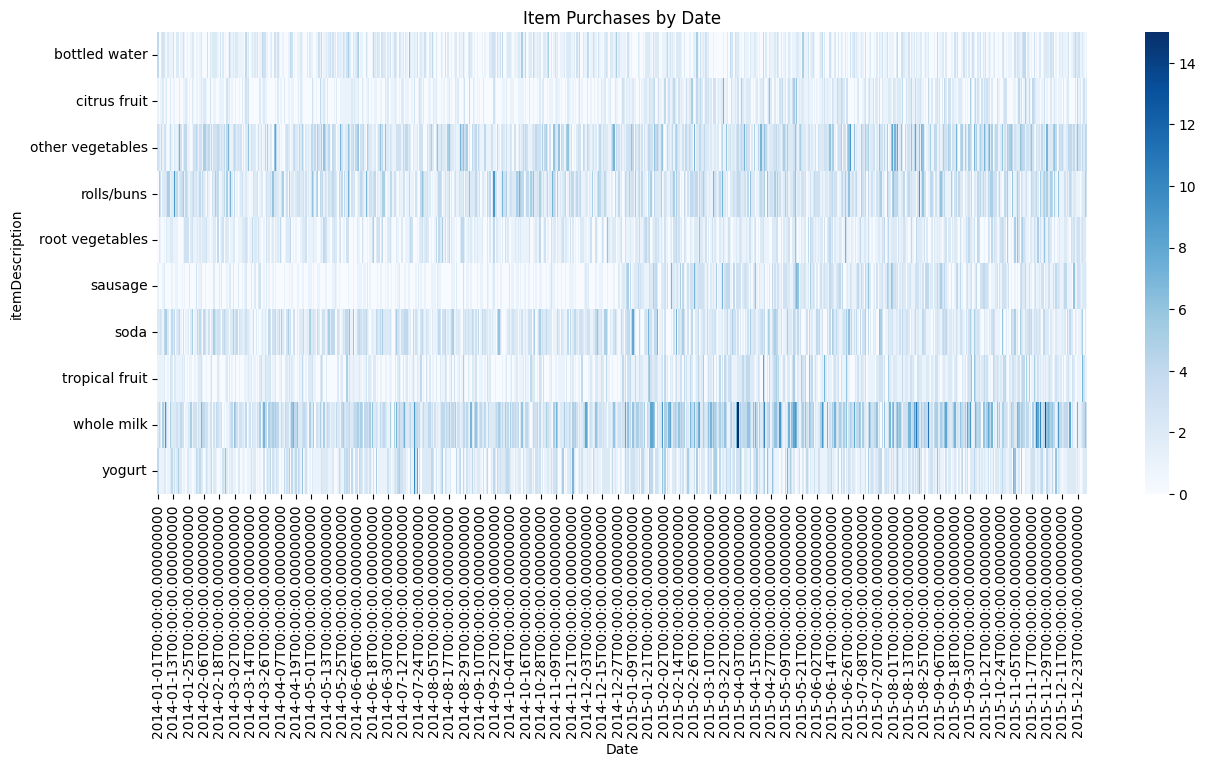

In [19]:
top_items = df['itemDescription'].value_counts().head(10).index

heatmap_data = (
    df[df['itemDescription'].isin(top_items)]
    .groupby(['Date', 'itemDescription'])
    .size()
    .unstack(fill_value=0)
)

import seaborn as sns

plt.figure(figsize=(15,6))
sns.heatmap(heatmap_data.T, cmap='Blues')
plt.title('Item Purchases by Date')
plt.show()

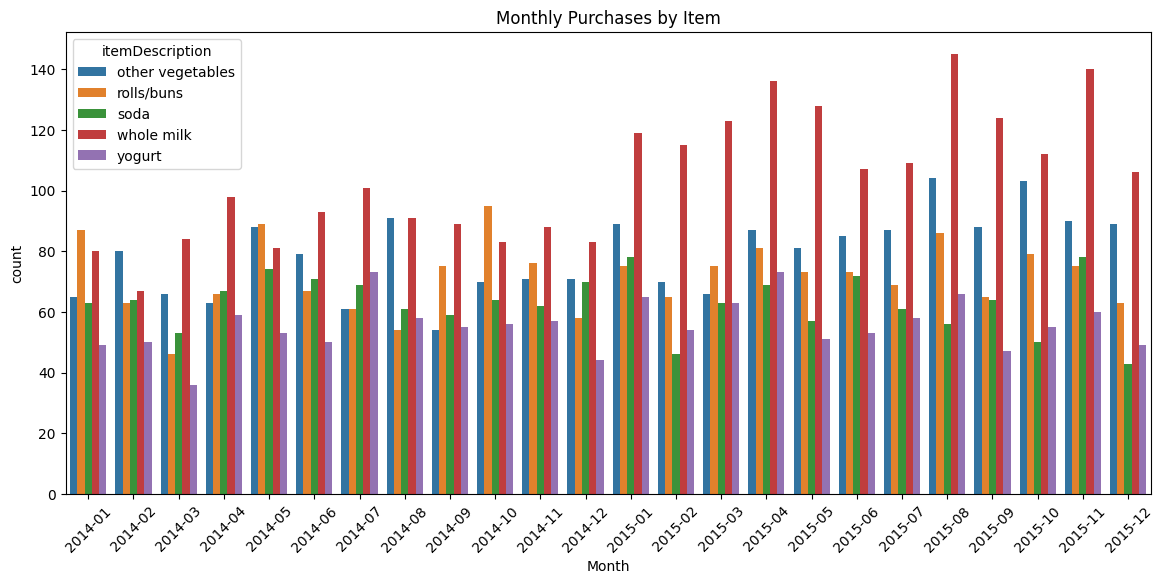

In [20]:
monthly_items = (
    df.groupby(['Month', 'itemDescription'])
      .size()
      .reset_index(name='count')
)

top_items = (
    df['itemDescription']
    .value_counts()
    .head(5)
    .index
)

monthly_items = monthly_items[
    monthly_items['itemDescription'].isin(top_items)
]

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
sns.barplot(
    data=monthly_items,
    x='Month',
    y='count',
    hue='itemDescription'
)

plt.xticks(rotation=45)
plt.title('Monthly Purchases by Item')
plt.show()

In [21]:
category_map = {
    'Dairy': [
        'whole milk','butter','butter milk','yogurt','curd cheese',
        'processed cheese','curd','hard cheese','cream cheese ',
        'UHT-milk','whipped/sour cream','sliced cheese','spread cheese',
        'soft cheese','cream','condensed milk'
    ],

    'Fruits & Vegetables': [
        'tropical fruit','pip fruit','other vegetables','citrus fruit',
        'berries','grapes','onions','root vegetables','herbs',
        'frozen vegetables','specialty vegetables',
        'packaged fruit/vegetables','canned vegetables',
        'canned fruit','frozen fruits','pickled vegetables'
    ],

    'Meat & Seafood': [
        'beef','frankfurter','chicken','sausage','hamburger meat',
        'pork','ham','turkey','fish','meat','frozen chicken',
        'frozen fish','organic sausage','liver loaf',
        'canned fish','meat spreads'
    ],

    'Bakery': [
        'rolls/buns','brown bread','pastry','white bread',
        'semi-finished bread','roll products ','zwieback',
        'long life bakery product','cake bar','waffles'
    ],

    'Beverages': [
        'fruit/vegetable juice','bottled water','coffee',
        'misc. beverages','soda','bottled beer','canned beer',
        'white wine','red/blush wine','sparkling wine',
        'liquor','liquor (appetizer)','prosecco',
        'brandy','rum','whisky','liqueur',
        'tea','instant coffee','cocoa drinks',
        'beverages','syrup'
    ],

    'Snacks & Sweets': [
        'chocolate','specialty chocolate','specialty bar',
        'candy','chewing gum','salty snack',
        'chocolate marshmallow','sweet spreads',
        'popcorn','nut snack','nuts/prunes',
        'honey','jam'
    ],

    'Frozen Foods': [
        'frozen meals','frozen potato products',
        'potato products','frozen dessert'
    ],

    'Household & Personal Care': [
        'detergent','cleaner','dish cleaner',
        'bathroom cleaner','toilet cleaner',
        'abrasive cleaner','softener','soap',
        'hygiene articles','female sanitary products',
        'dental care','skin care','make up remover',
        'male cosmetics','baby cosmetics',
        'hair spray','rubbing alcohol',
        'light bulbs','photo/film'
    ],

    'Pantry': [
        'flour','sugar','oil','salt','rice','pasta',
        'spices','mustard','mayonnaise','vinegar',
        'sauces','salad dressing','ketchup',
        'soups','ready soups','preservation products',
        'baking powder','pudding powder','cooking chocolate',
        'cereals'
    ],

    'Other': []
}

item_to_category = {}

for cat, items in category_map.items():
    for item in items:
        item_to_category[item] = cat

df['Category'] = df['itemDescription'].map(item_to_category)
df['Category'] = df['Category'].fillna('Other')

In [30]:
df

,Member_number,Date,itemDescription,Month,Category
0,1808,2015-07-21,tropical fruit,2015-07,Fruits & Vegetables
1,2552,2015-01-05,whole milk,2015-01,Dairy
2,2300,2015-09-19,pip fruit,2015-09,Fruits & Vegetables
3,1187,2015-12-12,other vegetables,2015-12,Fruits & Vegetables
4,3037,2015-02-01,whole milk,2015-02,Dairy
...,...,...,...,...,...
38760,4471,2014-10-08,sliced cheese,2014-10,Dairy
38761,2022,2014-02-23,candy,2014-02,Snacks & Sweets
38762,1097,2014-04-16,cake bar,2014-04,Bakery
38763,1510,2014-12-03,fruit/vegetable juice,2014-12,Beverages


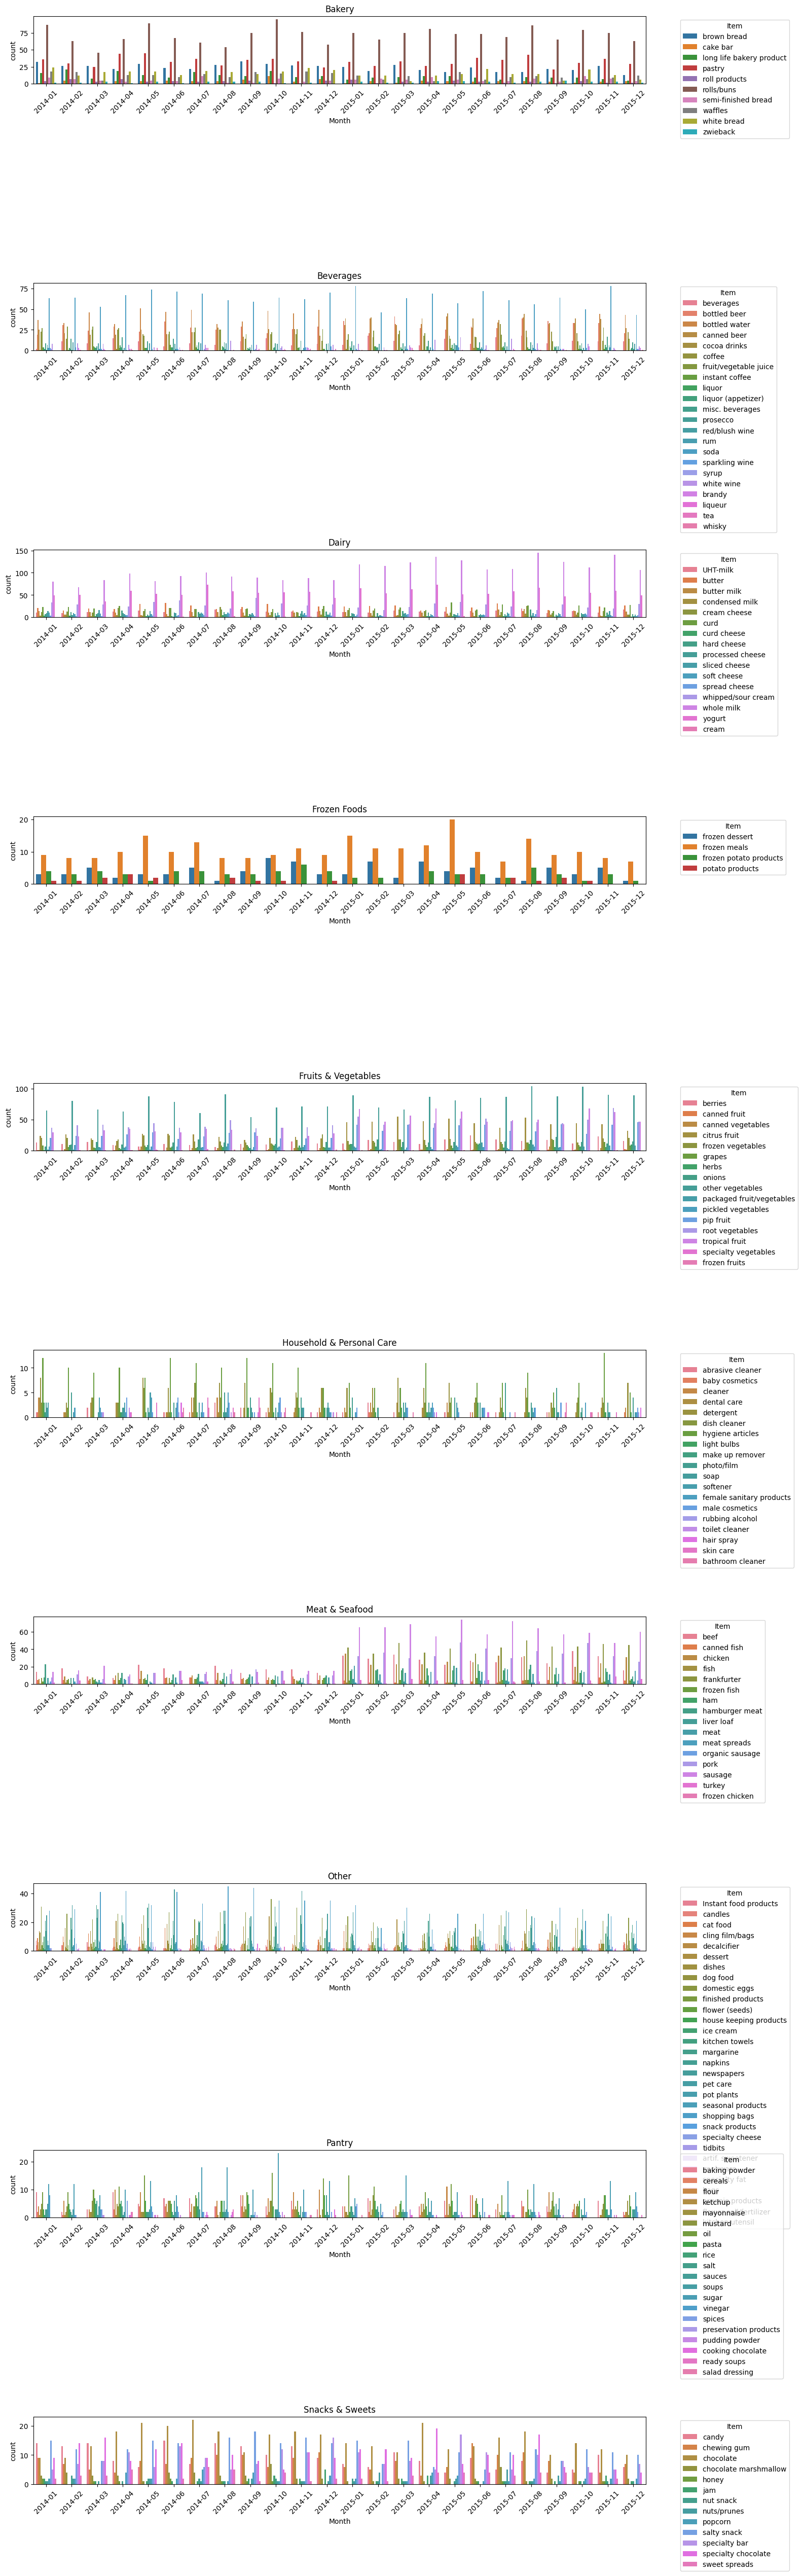

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

monthly_items = (
    df.groupby(['Month', 'Category', 'itemDescription'])
      .size()
      .reset_index(name='count')
)

categories = monthly_items['Category'].unique()

fig, axes = plt.subplots(
    nrows=len(categories),
    figsize=(16, 5*len(categories))
)

if len(categories) == 1:
    axes = [axes]

for ax, cat in zip(axes, categories):

    temp = monthly_items[
        monthly_items['Category'] == cat
    ]

    sns.barplot(
        data=temp,
        x='Month',
        y='count',
        hue='itemDescription',
        ax=ax
    )

    ax.set_title(cat)
    ax.tick_params(axis='x', rotation=45)

    ax.legend(
        bbox_to_anchor=(1.05, 1),
        loc='upper left',
        title='Item'
    )

plt.tight_layout()
plt.show()

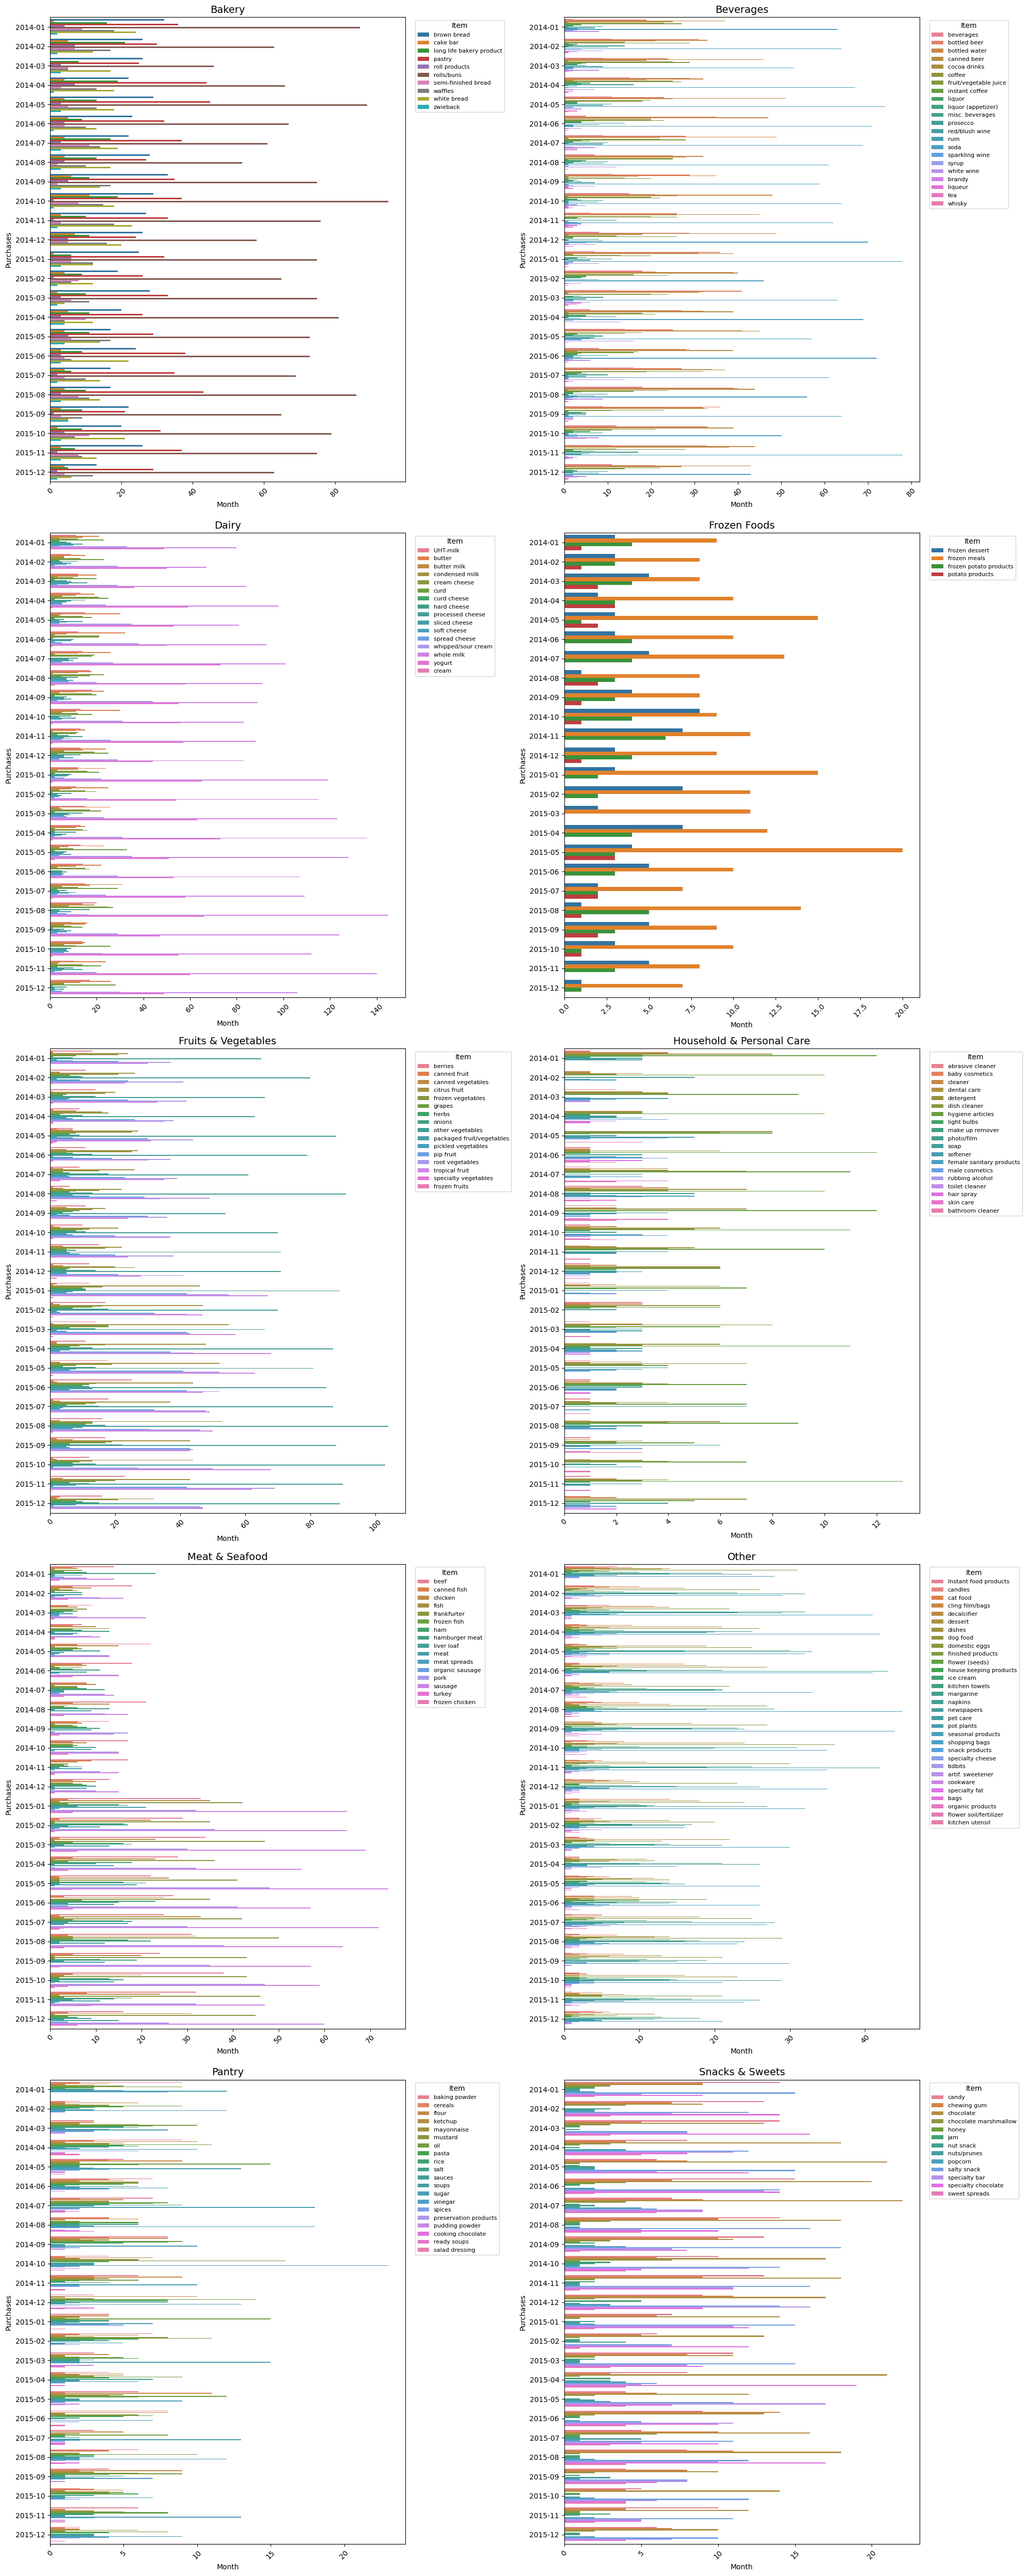

In [39]:
import pandas as pd
import numpy as np
import math
import seaborn as sns
import matplotlib.pyplot as plt

# Make sure Date is datetime
df['Date'] = pd.to_datetime(df['Date'])

# Create Month column
df['Month'] = df['Date'].dt.to_period('M')

# Convert Period to string for seaborn
df['Month'] = df['Month'].astype(str)


monthly_items = (
    df.groupby(['Month', 'Category', 'itemDescription'])
      .size()
      .reset_index(name='count')
)

# Ensure count is numeric
monthly_items['count'] = pd.to_numeric(monthly_items['count'])

categories = sorted(monthly_items['Category'].unique())

n_cols = 2
n_rows = math.ceil(len(categories) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(20, 10 * n_rows)
)

axes = np.array(axes).flatten()

for ax, category in zip(axes, categories):

    temp = monthly_items[
        monthly_items['Category'] == category
    ]

    """sns.barplot(
        data=temp,
        x='Month',
        y='count',
        hue='itemDescription',
        ax=ax
    )"""
    sns.barplot(
    data=temp,
    y='Month',          
    x='count',          
    hue='itemDescription',
    ax=ax,
    orient='h'
    )

    ax.set_title(category, fontsize=14)
    ax.set_ylabel('Month')
    ax.set_xlabel('Purchases')
    ax.tick_params(axis='x', rotation=45)

    ax.legend(
        title='Item',
        bbox_to_anchor=(1.02, 1),
        loc='upper left',
        fontsize=8
    )

# Remove empty axes
for ax in axes[len(categories):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

In [40]:
df['Member_number'].nunique()

3898

In [54]:
from IPython.display import FileLink

df.to_csv("df_Groceries_dataset.csv", index=False)
FileLink("df_Groceries_dataset.csv")

/kaggle/working/df_Groceries_dataset.csv

In [42]:
#bar plot -> x-axis:Member_number , y-axis: count , hue: Category

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


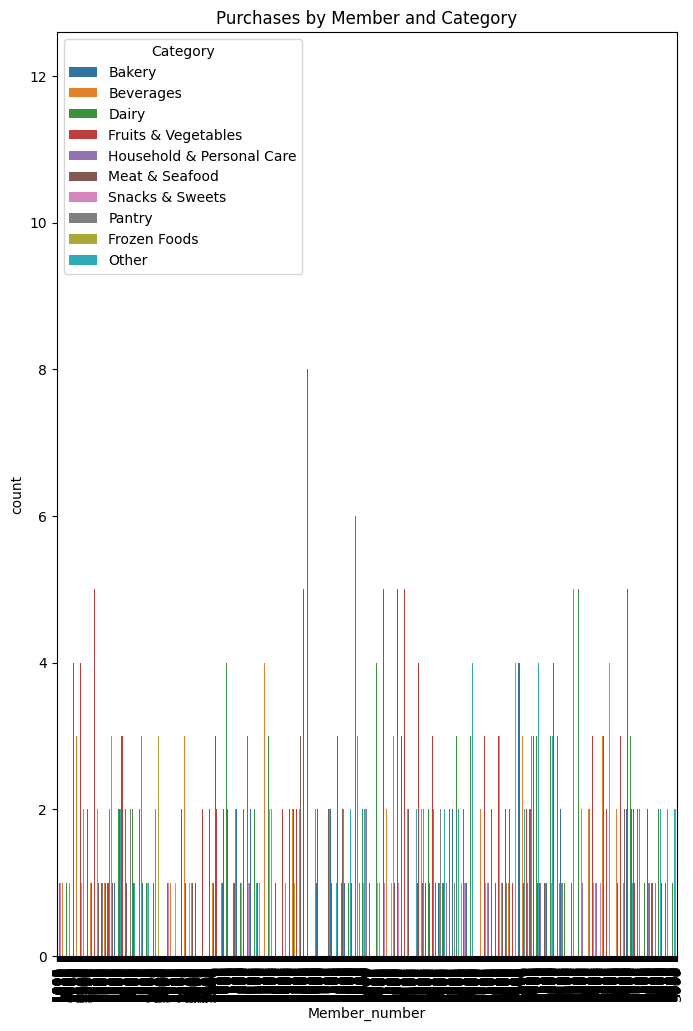

In [46]:
member_category = (
    df.groupby(['Member_number', 'Category'])
      .size()
      .reset_index(name='count')
)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,12))

sns.barplot(
    data=member_category,
    y='Member_number',
    x='count',
    hue='Category',
    ax=ax,
    orient='h'
)

plt.xticks(rotation=90)
plt.title('Purchases by Member and Category')
plt.show()

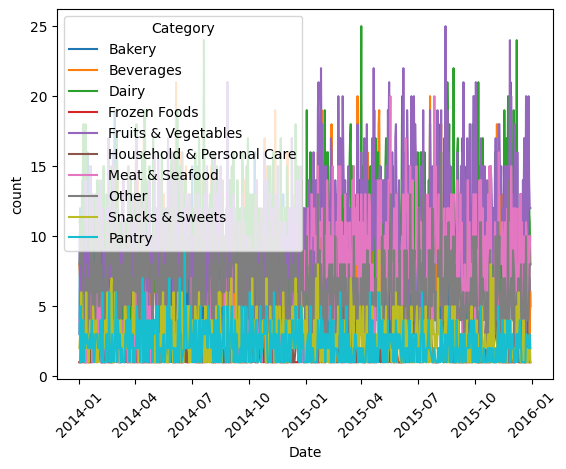

In [47]:
member_cat_date = (
    df.groupby(['Date', 'Category'])
      .size()
      .reset_index(name='count')
)

sns.lineplot(
    data=member_cat_date,
    x='Date',
    y='count',
    hue='Category'
)

plt.xticks(rotation=45)
plt.show()

In [55]:
pivot_table = pd.pivot_table(
    member_cat_month,
    values='count',
    index=['Month', 'Member_number'],
    columns='Category',
    fill_value=0
)

pivot_table

Category               Bakery  Beverages  Dairy  Frozen Foods  \
Month   Member_number                                           
2014-01 1003              0.0        0.0    0.0           1.0   
        1005              2.0        0.0    1.0           0.0   
        1009              0.0        1.0    0.0           0.0   
        1013              0.0        1.0    1.0           0.0   
        1032              0.0        0.0    1.0           0.0   
...                       ...        ...    ...           ...   
2015-12 4985              0.0        0.0    1.0           0.0   
        4988              1.0        0.0    0.0           0.0   
        4990              0.0        0.0    0.0           0.0   
        4997              0.0        1.0    1.0           0.0   
        4999              0.0        1.0    0.0           0.0   

Category               Fruits & Vegetables  Household & Personal Care  \
Month   Member_number                                                   
2014-01 1003                           0.0                        1.0   
        1005                           0.0                        0.0   
        1009                           0.0                        0.0   
        1013                           0.0                        0.0   
        1032                           0.0                        0.0   
...                                    ...                        ...   
2015-12 4985                           1.0                        0.0   
        4988                           0.0                        0.0   
        4990                           1.0                        0.0   
        4997                           2.0                        0.0   
        4999                           1.0                        0.0   

Category               Meat & Seafood  Other  Pantry  Snacks & Sweets  
Month   Member_number                                                  
2014-01 1003                      0.0    0.0     0.0              0.0  
        1005                      0.0    1.0     0.0              0.0  
        1009                      1.0    0.0     0.0              0.0  
        1013                      0.0    1.0     0.0              0.0  
        1032                      0.0    1.0     0.0              0.0  
...                               ...    ...     ...              ...  
2015-12 4985                      0.0    0.0     0.0              0.0  
        4988                      1.0    0.0     0.0              0.0  
        4990                      0.0    0.0     0.0              1.0  
        4997                      0.0    0.0     0.0              0.0  
        4999                      0.0    0.0     0.0              0.0  

[13905 rows x 10 columns]

In [57]:
pivot_table = pd.pivot_table(
    member_cat_month,
    values='count',
    index=['Month', 'Member_number'],
    columns='Category',
    fill_value=0
)

pivot_table

Category               Bakery  Beverages  Dairy  Frozen Foods  \
Month   Member_number                                           
2014-01 1003              0.0        0.0    0.0           1.0   
        1005              2.0        0.0    1.0           0.0   
        1009              0.0        1.0    0.0           0.0   
        1013              0.0        1.0    1.0           0.0   
        1032              0.0        0.0    1.0           0.0   
...                       ...        ...    ...           ...   
2015-12 4985              0.0        0.0    1.0           0.0   
        4988              1.0        0.0    0.0           0.0   
        4990              0.0        0.0    0.0           0.0   
        4997              0.0        1.0    1.0           0.0   
        4999              0.0        1.0    0.0           0.0   

Category               Fruits & Vegetables  Household & Personal Care  \
Month   Member_number                                                   
2014-01 1003                           0.0                        1.0   
        1005                           0.0                        0.0   
        1009                           0.0                        0.0   
        1013                           0.0                        0.0   
        1032                           0.0                        0.0   
...                                    ...                        ...   
2015-12 4985                           1.0                        0.0   
        4988                           0.0                        0.0   
        4990                           1.0                        0.0   
        4997                           2.0                        0.0   
        4999                           1.0                        0.0   

Category               Meat & Seafood  Other  Pantry  Snacks & Sweets  
Month   Member_number                                                  
2014-01 1003                      0.0    0.0     0.0              0.0  
        1005                      0.0    1.0     0.0              0.0  
        1009                      1.0    0.0     0.0              0.0  
        1013                      0.0    1.0     0.0              0.0  
        1032                      0.0    1.0     0.0              0.0  
...                               ...    ...     ...              ...  
2015-12 4985                      0.0    0.0     0.0              0.0  
        4988                      1.0    0.0     0.0              0.0  
        4990                      0.0    0.0     0.0              1.0  
        4997                      0.0    0.0     0.0              0.0  
        4999                      0.0    0.0     0.0              0.0  

[13905 rows x 10 columns]

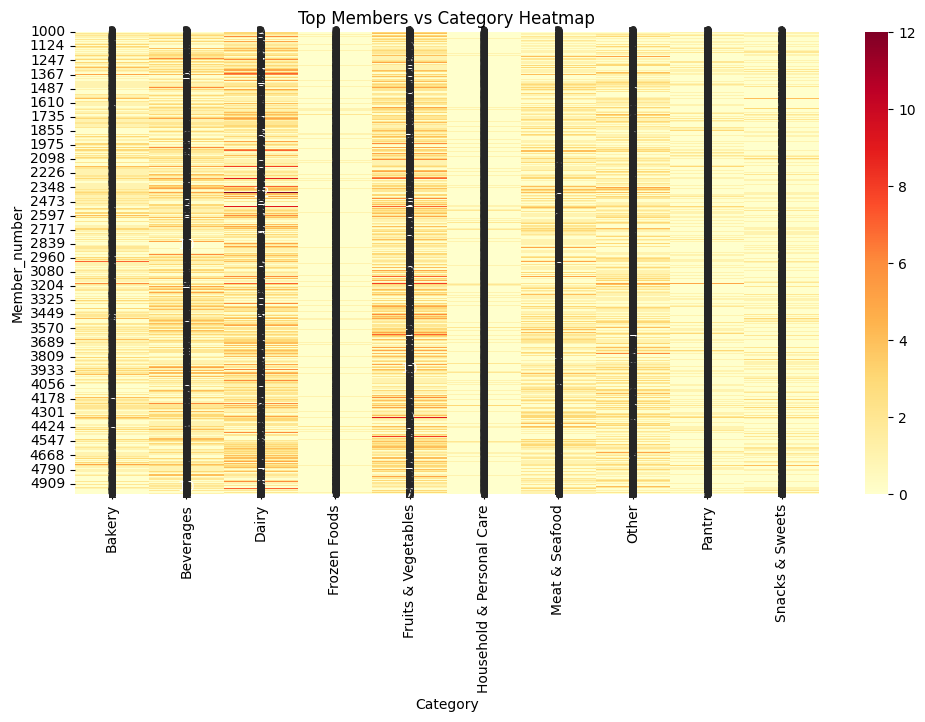

In [59]:
top_members = (
    df['Member_number']
    .value_counts()
    #.head(30)
    .index
)

pivot = pd.pivot_table(
    member_cat_month[member_cat_month['Member_number'].isin(top_members)],
    values='count',
    index='Member_number',
    columns='Category',
    aggfunc='sum',
    fill_value=0
)

plt.figure(figsize=(12,6))

sns.heatmap(
    pivot,
    cmap='YlOrRd',
    annot=True,   # shows numbers
    fmt='g'
)

plt.title('Top Members vs Category Heatmap')
plt.show()

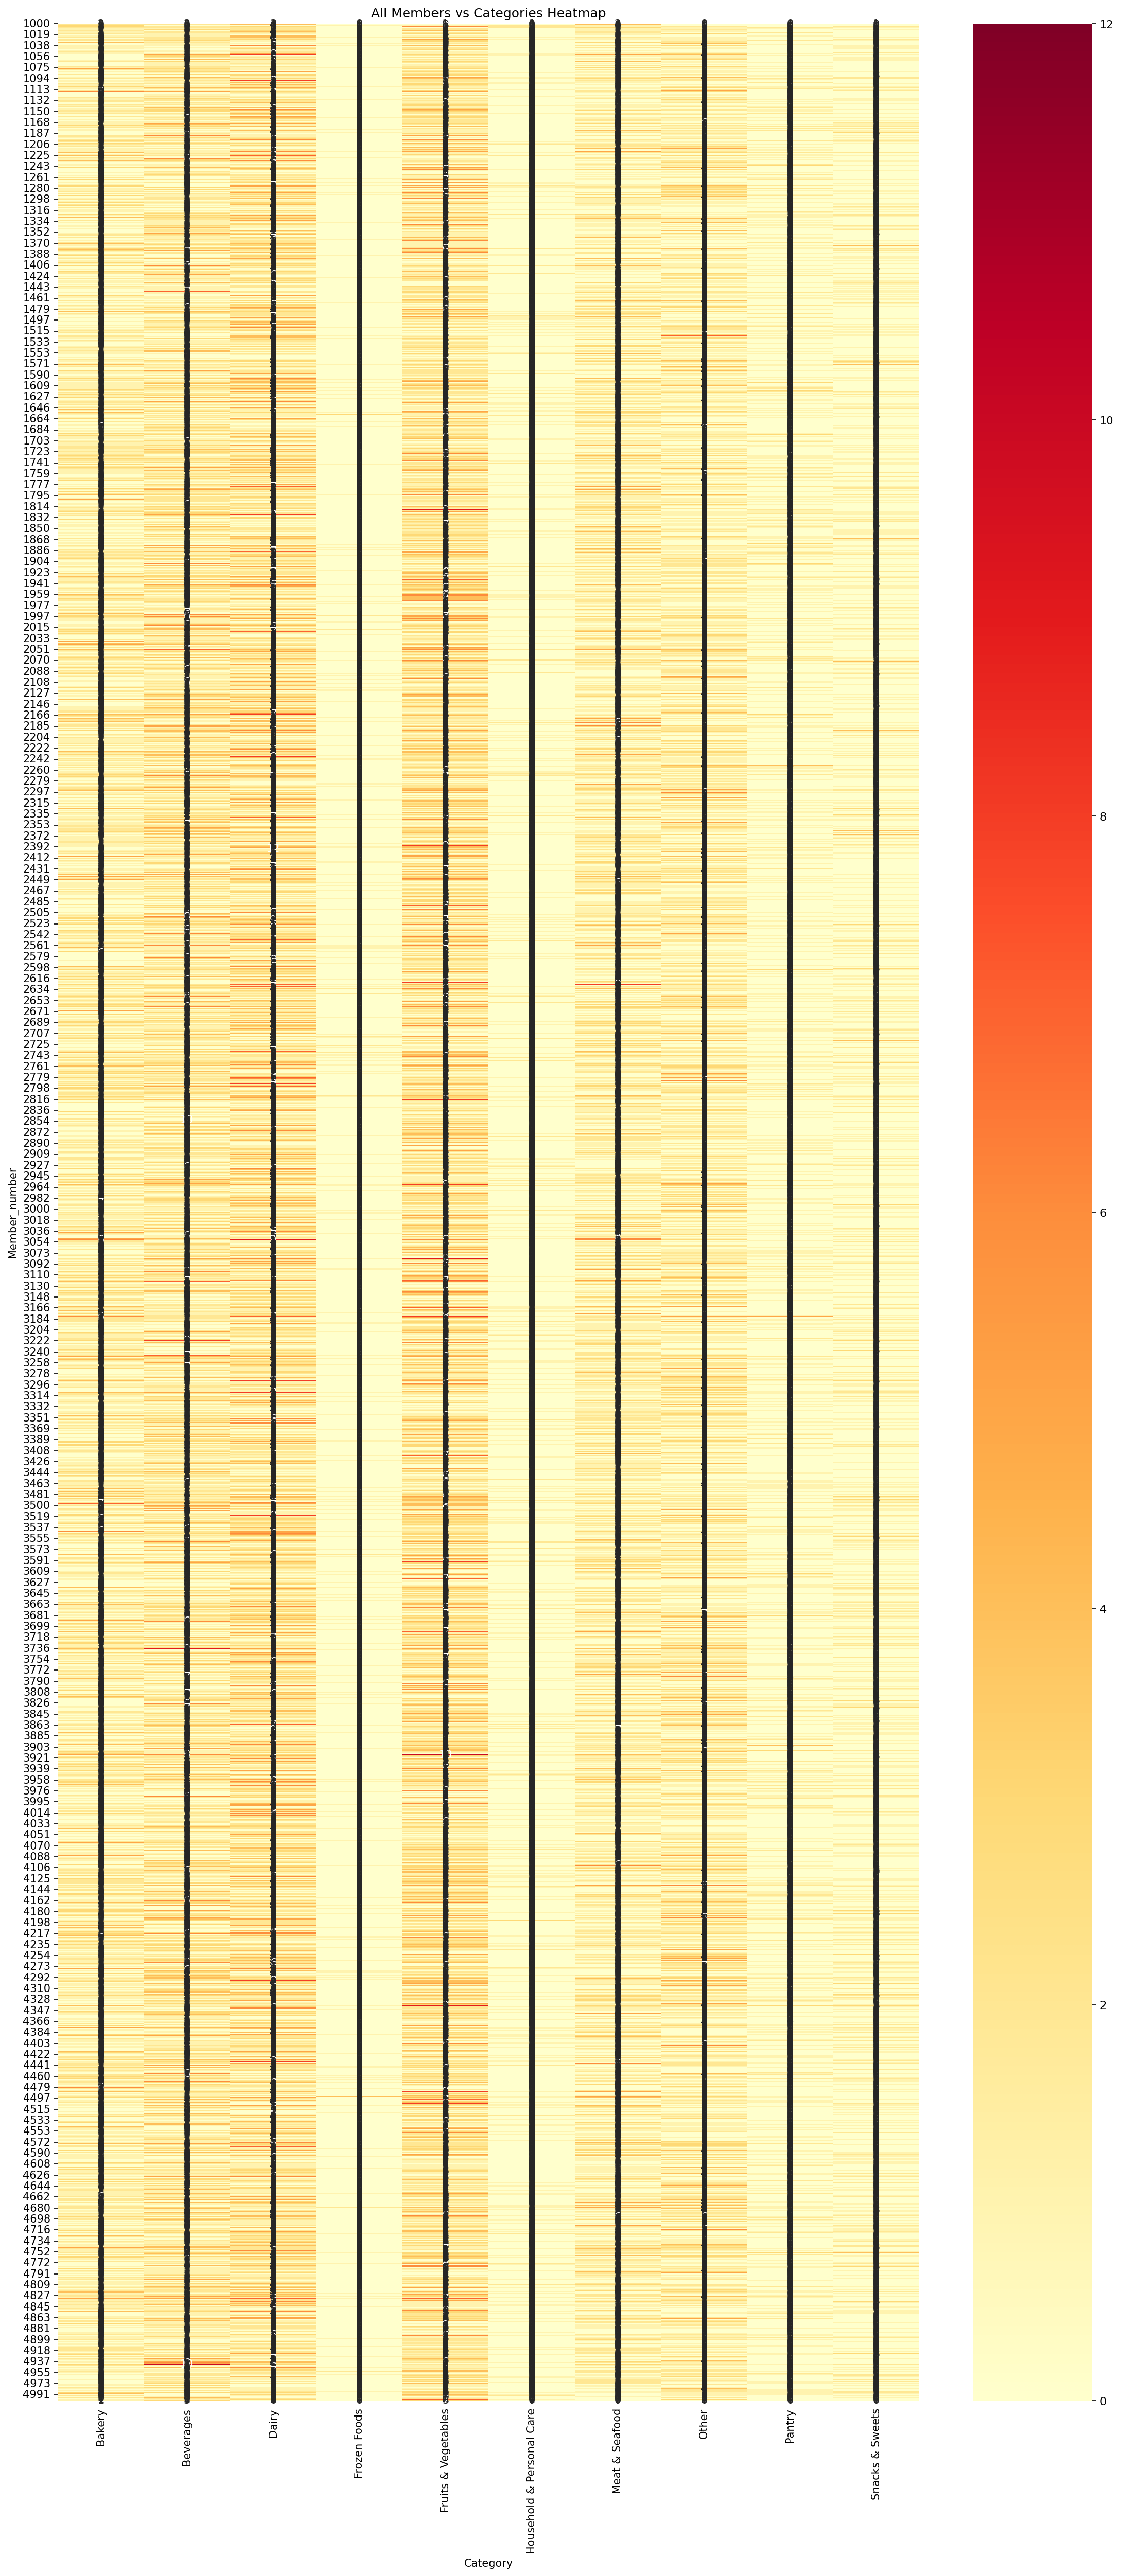

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Ensure month exists
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.to_period('M').astype(str)

# Aggregate
member_cat_month = (
    df.groupby(['Member_number', 'Category'])
      .size()
      .reset_index(name='count')
)

# Pivot (ALL members included)
pivot = pd.pivot_table(
    member_cat_month,
    values='count',
    index='Member_number',
    columns='Category',
    aggfunc='sum',
    fill_value=0
)

# Plot heatmap
plt.figure(figsize=(18, 40), dpi=150)

sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt='g')

plt.title('All Members vs Categories Heatmap')
plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#1f77b4'` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#1f77b4'` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#1f77b4'` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#1f77b4'` for the same effect.

  func(*plot_args, **p

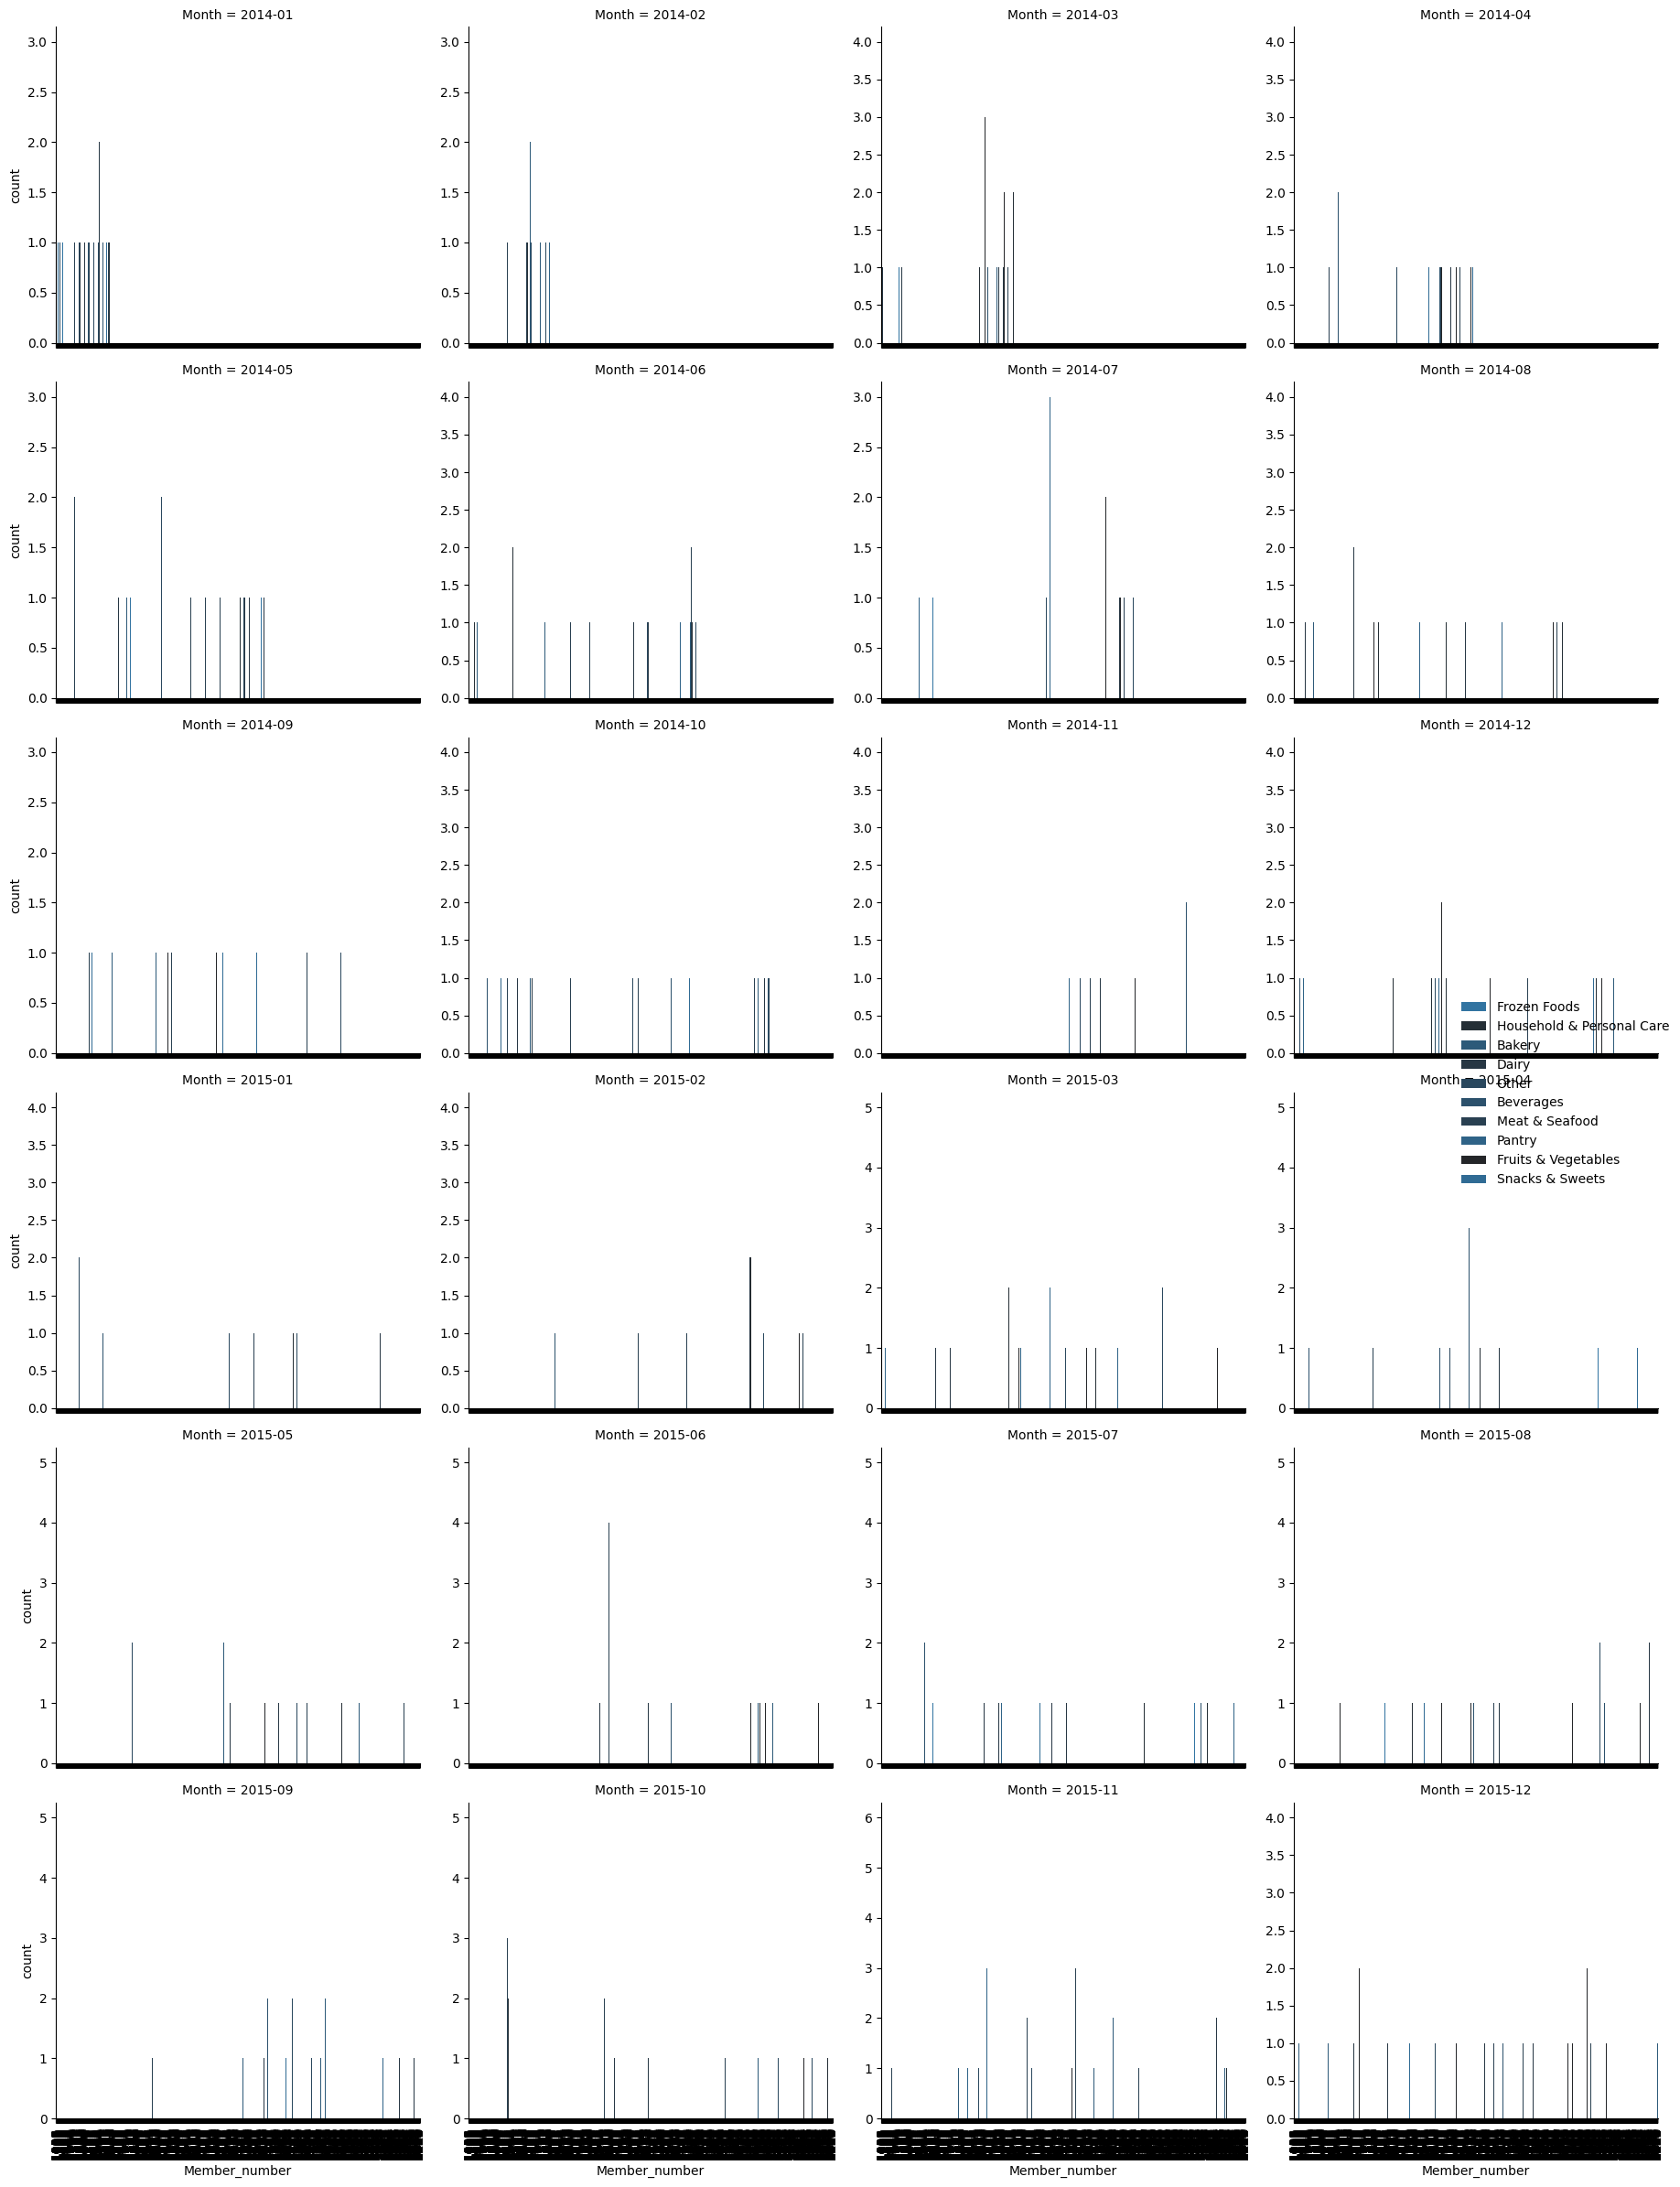

In [52]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.to_period('M').astype(str)

member_cat_month = (
    df.groupby(['Month', 'Member_number', 'Category'])
      .size()
      .reset_index(name='count')
)

g = sns.FacetGrid(
    member_cat_month,
    col='Month',
    col_wrap=3,      
    height=4,
    sharey=False
)

g.map_dataframe(
    sns.barplot,
    x='Member_number',
    y='count',
    hue='Category',
    errorbar=None
)

for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=90)

g.add_legend()

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#1f77b4'` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#1f77b4'` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#1f77b4'` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#1f77b4'` for the same effect.

  func(*plot_args, **p

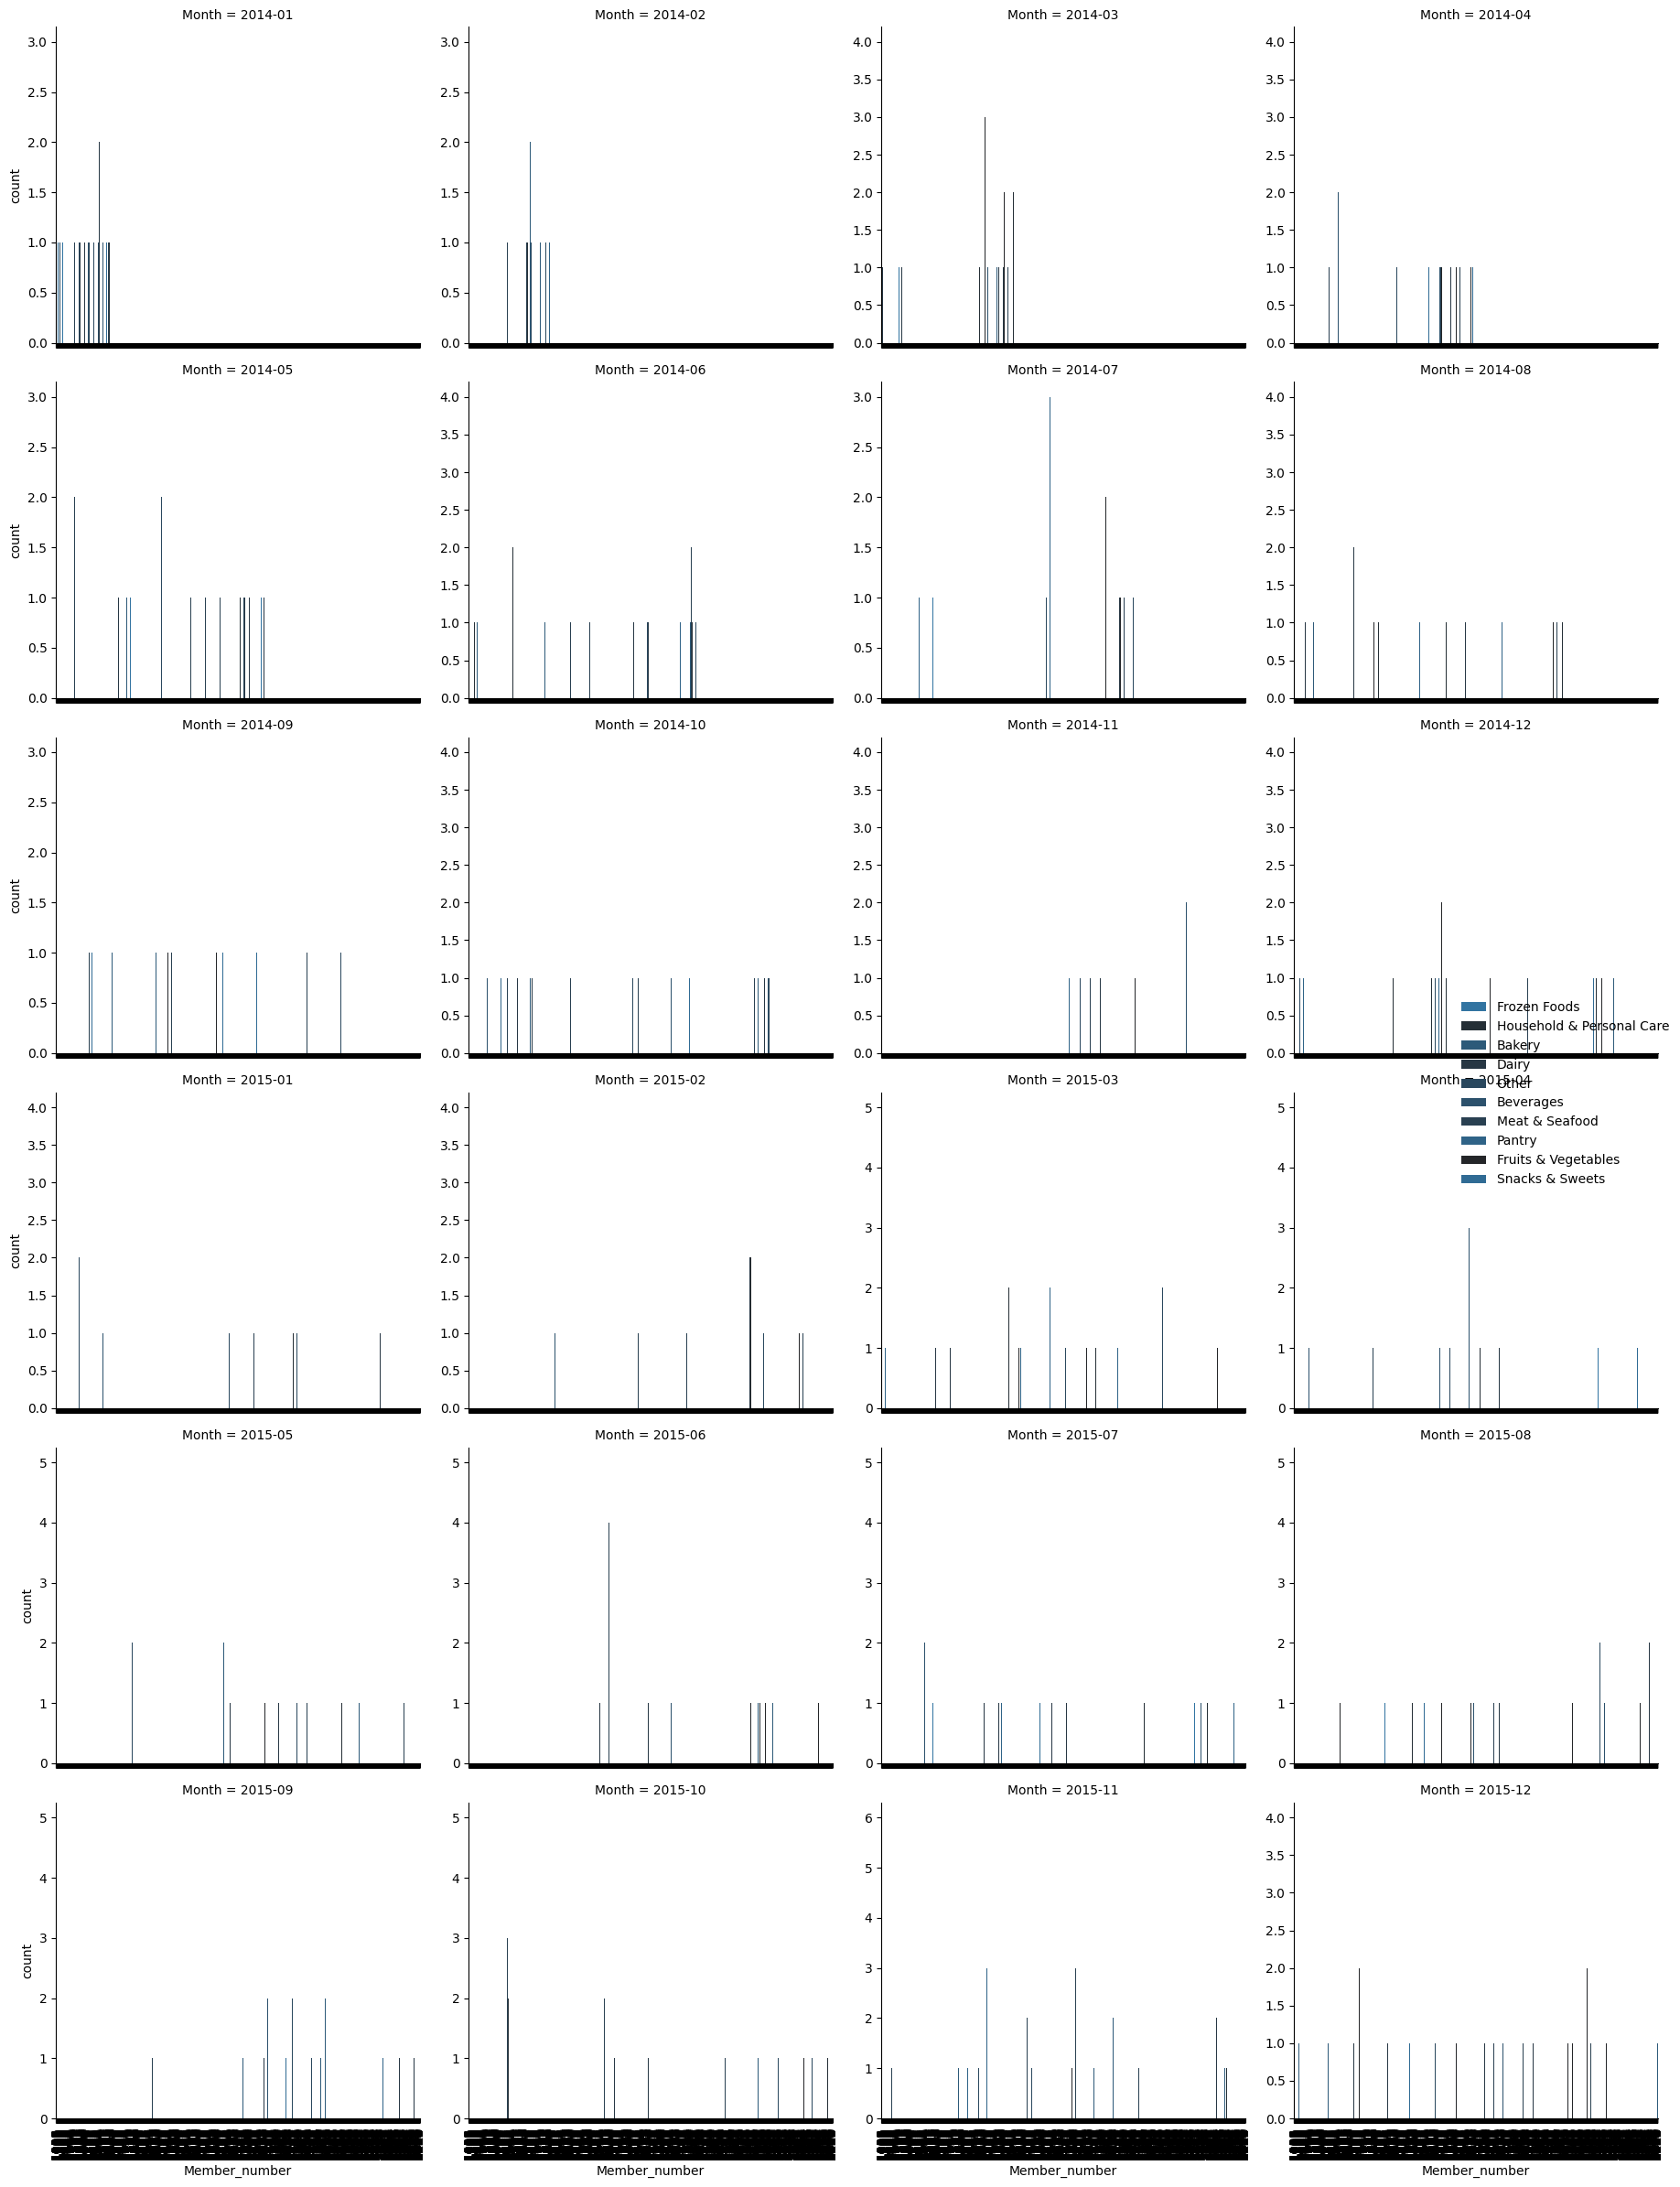

In [53]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df['Date'] = pd.to_datetime(df['Date'])

df['Month'] = df['Date'].dt.to_period('M').astype(str)

top_members = (
    df['Member_number']
    .value_counts()
    #.head(20)
    .index
)

df_top = df[df['Member_number'].isin(top_members)]

member_cat_month = (
    df_top.groupby(['Month', 'Member_number', 'Category'])
          .size()
          .reset_index(name='count')
)

g = sns.FacetGrid(
    member_cat_month,
    col='Month',
    col_wrap=4,
    height=4,
    sharey=False
)

g.map_dataframe(
    sns.barplot,
    x='Member_number',
    y='count',
    hue='Category'
)

for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=90)

g.add_legend()

plt.tight_layout()
plt.show()

In [22]:
import pandas as pd

basket = df.pivot_table(
    index='Member_number',
    columns='Category',
    values='itemDescription',
    aggfunc='count',
    fill_value=0
)

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(basket)

In [24]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
basket['cluster'] = kmeans.fit_predict(X_scaled)

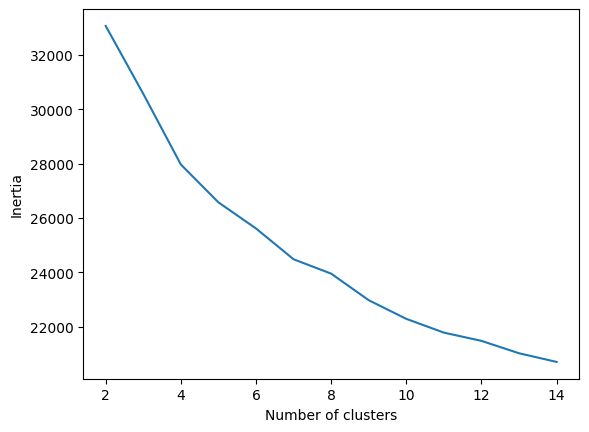

In [25]:
import matplotlib.pyplot as plt

inertia = []
K = range(2, 15)

for k in K:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.plot(K, inertia)
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.show()

In [26]:
cluster_summary = basket.groupby('cluster').mean()
print(cluster_summary)

Category    Bakery  Beverages     Dairy  Frozen Foods  Fruits & Vegetables  \
cluster                                                                      
0         1.200000   1.781081  2.029730      1.089189             2.032432   
1         1.705757   1.782516  2.380597      0.000000             2.286780   
2         1.727862   2.965443  3.505400      0.053996             3.334773   
3         0.514612   0.934562  1.089581      0.000000             1.113723   
4         1.276673   1.698011  2.097649      0.019892             2.144665   

Category  Household & Personal Care  Meat & Seafood     Other    Pantry  \
cluster                                                                   
0                          0.197297        1.221622  1.256757  0.410811   
1                          0.000000        1.329424  1.621535  0.271855   
2                          0.149028        2.120950  1.883369  1.060475   
3                          0.013977        0.594028  0.641042  0.254130   
4  

In [27]:
def recommend(member_id, top_n=5):
    cluster = basket.loc[member_id, 'cluster']
    
    cluster_customers = basket[basket['cluster'] == cluster].drop('cluster', axis=1)
    
    top_products = cluster_customers.sum().sort_values(ascending=False)
    
    already_bought = basket.loc[member_id].drop('cluster')
    
    recommendations = top_products[already_bought == 0].head(top_n)
    
    return recommendations

In [29]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=10, random_state=42)
basket['cluster'] = kmeans.fit_predict(X_scaled)

basket['cluster'].value_counts().sort_index()

cluster_profile = basket.groupby('cluster').mean()
print(cluster_profile)

Category    Bakery  Beverages     Dairy  Frozen Foods  Fruits & Vegetables  \
cluster                                                                      
0         0.781250   2.211538  2.701923      0.002404             2.918269   
1         0.957507   1.535411  2.354108      0.008499             1.779037   
2         0.739535   1.123256  1.406977      0.002326             1.434884   
3         1.152299   1.727011  1.968391      1.094828             1.974138   
4         0.426131   0.861307  0.995980      0.000000             1.035176   
5         0.924658   1.191781  1.558219      0.013699             1.493151   
6         1.636719   2.417969  2.718750      0.031250             2.871094   
7         2.615385   3.567308  4.466346      0.139423             3.870192   
8         2.773585   1.576819  1.695418      0.002695             1.805930   
9         1.275109   1.820961  2.344978      0.048035             2.436681   

Category  Household & Personal Care  Meat & Seafood     Other  

In [31]:
user_cluster = basket['cluster']

cluster_profile = basket.groupby('cluster').mean()

cluster_rankings = cluster_profile.apply(
    lambda row: row.sort_values(ascending=False).index.tolist(),
    axis=1
)

In [32]:
def recommend_categories(member_id, top_n=3):
    cluster = basket.loc[member_id, 'cluster']
    
    user_data = basket.loc[member_id].drop('cluster')
    
    ranked_categories = cluster_profile.loc[cluster].sort_values(ascending=False)
    
    recommendations = ranked_categories[user_data == 0].head(top_n)
    
    return recommendations

In [33]:
basket = df.pivot_table(
    index='Member_number',
    columns='Category',
    values='itemDescription',
    aggfunc='count',
    fill_value=0
)
basket['cluster'] = kmeans.fit_predict(X_scaled)

In [34]:
basket

Category,Bakery,Beverages,Dairy,Frozen Foods,Fruits & Vegetables,Household & Personal Care,Meat & Seafood,Other,Pantry,Snacks & Sweets,cluster
Member_number,,,,,,,,,,,
1000,2,3,3,0,1,1,2,0,0,1,5
1001,2,2,4,0,0,0,4,0,0,0,0
1002,0,0,3,0,3,0,0,0,1,1,2
1003,3,0,0,1,1,2,1,0,0,0,5
1004,3,2,3,0,6,2,1,2,0,2,6
...,...,...,...,...,...,...,...,...,...,...,...
4996,2,4,0,0,1,0,0,2,0,1,8
4997,0,2,2,0,2,0,0,0,0,0,4
4998,1,0,1,0,0,0,0,0,0,0,4


In [36]:
member_to_cluster = basket['cluster']

df['cluster'] = df['Member_number'].map(member_to_cluster)

In [37]:
cluster_items = (
    df.groupby(['cluster', 'itemDescription'])
      .size()
      .reset_index(name='count')
)

In [38]:
df

,Member_number,Date,itemDescription,Month,Category,cluster
0,1808,2015-07-21,tropical fruit,2015-07,Fruits & Vegetables,8
1,2552,2015-01-05,whole milk,2015-01,Dairy,6
2,2300,2015-09-19,pip fruit,2015-09,Fruits & Vegetables,5
3,1187,2015-12-12,other vegetables,2015-12,Fruits & Vegetables,4
4,3037,2015-02-01,whole milk,2015-02,Dairy,4
...,...,...,...,...,...,...
38760,4471,2014-10-08,sliced cheese,2014-10,Dairy,2
38761,2022,2014-02-23,candy,2014-02,Snacks & Sweets,7
38762,1097,2014-04-16,cake bar,2014-04,Bakery,0
38763,1510,2014-12-03,fruit/vegetable juice,2014-12,Beverages,3


In [41]:
for cluster, data in df.groupby('cluster'):
    print("\nCluster:", cluster)
    print(data)

cluster_groups = dict(tuple(df.groupby('cluster')))


Cluster: 0
       Member_number       Date        itemDescription    Month  \
6               4501 2015-05-08       other vegetables  2015-05   
9               4119 2015-02-12         tropical fruit  2015-02   
14              4736 2015-07-21                 butter  2015-07   
21              2867 2015-11-12             whole milk  2015-11   
32              4289 2015-10-08                   pork  2015-10   
...              ...        ...                    ...      ...   
38740           1045 2014-04-10  Instant food products  2014-04   
38747           2639 2014-06-08  fruit/vegetable juice  2014-06   
38752           2824 2014-09-05        cling film/bags  2014-09   
38754           4796 2014-03-02  Instant food products  2014-03   
38762           1097 2014-04-16               cake bar  2014-04   

                  Category  cluster  
6      Fruits & Vegetables        0  
9      Fruits & Vegetables        0  
14                   Dairy        0  
21                   Dairy     

In [48]:
df_cluster_counts = df.sort_values('cluster')
print(df_cluster_counts)

       Member_number       Date   itemDescription    Month  \
14              4736 2015-07-21            butter  2015-07   
9               4119 2015-02-12    tropical fruit  2015-02   
6               4501 2015-05-08  other vegetables  2015-05   
12287           4261 2014-05-29   root vegetables  2014-05   
12283           4362 2014-01-22       chewing gum  2014-01   
...              ...        ...               ...      ...   
31780           4302 2014-11-26   misc. beverages  2014-11   
31797           1094 2014-03-11       brown bread  2014-03   
12288           4683 2014-03-02   cling film/bags  2014-03   
25              4056 2015-06-12            yogurt  2015-06   
38759           3364 2014-05-06               oil  2014-05   

                  Category  cluster  
14                   Dairy        0  
9      Fruits & Vegetables        0  
6      Fruits & Vegetables        0  
12287  Fruits & Vegetables        0  
12283      Snacks & Sweets        0  
...                    ... 

In [49]:
df_cluster_counts

,Member_number,Date,itemDescription,Month,Category,cluster
14,4736,2015-07-21,butter,2015-07,Dairy,0
9,4119,2015-02-12,tropical fruit,2015-02,Fruits & Vegetables,0
6,4501,2015-05-08,other vegetables,2015-05,Fruits & Vegetables,0
12287,4261,2014-05-29,root vegetables,2014-05,Fruits & Vegetables,0
12283,4362,2014-01-22,chewing gum,2014-01,Snacks & Sweets,0
...,...,...,...,...,...,...
31780,4302,2014-11-26,misc. beverages,2014-11,Beverages,9
31797,1094,2014-03-11,brown bread,2014-03,Bakery,9
12288,4683,2014-03-02,cling film/bags,2014-03,Other,9
25,4056,2015-06-12,yogurt,2015-06,Dairy,9


In [50]:
from IPython.display import FileLink

df.to_csv("df_Groceries_cluster.csv", index=False)
FileLink("df_Groceries_cluster.csv")

/kaggle/working/df_Groceries_cluster.csv